# Notebook 02 — Nettoyage des 3 sources de données

**Objectif de ce notebook :** nettoyer séparément les 3 fichiers bruts du projet, chacun dans
sa propre partie ci-dessous (elles sont indépendantes entre elles — aucune des trois ne lit le
résultat d'une autre — et ne sont regroupées ici que pour la lisibilité du projet) :

- **Partie A — Caractéristiques** (`datashare.parquet`) : décider de la période de départ, réduire
  les 94 caractéristiques de Gu, Kelly & Xiu (2020) à un sous-ensemble gérable, nettoyer le
  secteur (`sic2`)
- **Partie B — Rendements** (`StockReturn.parquet`) : repérer et convertir les codes CRSP non
  numériques de `RET`, retirer les rendements manquants (jamais les imputer, c'est la cible)
- **Partie C — Variables macro** (`MacroData.parquet`) : restreindre à la période utile, construire
  les 8 prédicteurs macro de GKX à partir des colonnes brutes de Welch & Goyal

Chaque partie sauvegarde son propre fichier dans `data/interim/` (format Parquet) :
`characteristics_clean.parquet`, `returns_clean.parquet`, `macro_clean.parquet`. La fusion des
trois se fait au notebook suivant (**03 — Construction du panel**, partie A).


## 0. Import des bibliothèques

Un seul bloc d'imports, réutilisé par les 3 parties ci-dessous.

In [1]:
import pandas as pd
import numpy as np
import json
import sys
sys.path.append("..")  # pour pouvoir importer config.py, situe a la racine du projet
import config

config.assurer_dossiers()  # cree data/interim, data/processed, modeles/, outputs/ si absents

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## Partie A — Nettoyage des caractéristiques (`datashare.parquet`)

Cette partie lit `data/raw/datashare.parquet` et ne touche à aucun autre fichier. Elle sauvegarde
`data/interim/characteristics_clean.parquet`.

### A.1 Chargement des données brutes

In [2]:
chars = pd.read_parquet(config.FICHIER_CARACTERISTIQUES_BRUT)
print("Dimensions de depart :", chars.shape)
chars.head()


Dimensions de depart : (4117300, 97)


,permno,DATE,mvel1,beta,betasq,chmom,dolvol,idiovol,indmom,mom1m,...,stdcf,ms,baspread,ill,maxret,retvol,std_dolvol,std_turn,zerotrade,sic2
0,10006,19570131,82249.000,1.122846,1.260784,0.047180,9.569953,0.025742,0.046433,0.044843,...,NaN,NaN,0.013234,9.411565e-08,0.015453,0.008058,0.355638,0.460420,1.120996e-07,37.0
1,10014,19570131,3903.375,0.426734,0.182102,-0.275641,6.237836,0.072103,0.046433,-0.086957,...,NaN,NaN,0.033305,6.610609e-06,0.047619,0.033495,1.152126,1.169610,9.229146e-08,NaN
2,10022,19570131,9273.250,1.066449,1.137313,-0.025490,7.008844,0.027648,0.046433,-0.060377,...,NaN,NaN,0.016023,2.286832e-06,0.020833,0.015589,0.815777,0.679803,1.181757e-07,NaN
3,10030,19570131,54465.875,0.926038,0.857547,0.018171,9.825337,0.021700,0.046433,0.044633,...,NaN,NaN,0.015295,1.464273e-07,0.039326,0.015849,0.739302,1.333656,6.126699e-08,NaN
4,10057,19570131,40250.000,1.247748,1.556875,0.025785,7.901007,0.025506,0.046433,0.086667,...,NaN,NaN,0.005954,1.380375e-06,0.056856,0.019945,0.755510,0.410391,3.315790e+00,NaN


### A.2 Décider de la période de départ

Avant de choisir les colonnes à garder, on regarde comment le taux de valeurs manquantes
évolue dans le temps. Beaucoup de caractéristiques comptables ne sont fiables qu'à partir
des années 1970-1980 (couverture Compustat plus complète), donc démarrer en 1957 comme le
fait GKX ajoute surtout des lignes très incomplètes.

In [3]:
# On cree une colonne "decennie" pour resumer le taux de missing dans le temps
chars['annee'] = chars['DATE'] // 10000
chars['decennie'] = (chars['annee'] // 10) * 10

colonnes_predicteurs = [c for c in chars.columns if c not in
                        ['permno', 'DATE', 'sic2', 'annee', 'decennie']]

# Taux moyen de valeurs manquantes (toutes caracteristiques confondues), par decennie
missing_par_decennie = (
    chars.groupby('decennie')[colonnes_predicteurs]
         .apply(lambda g: g.isna().mean().mean())
         .rename("taux_missing_moyen")
)
(missing_par_decennie * 100).round(1)


decennie
1950    79.0
1960    63.2
1970    38.9
1980    32.2
1990    26.7
2000    20.9
2010    21.8
2020    33.3
Name: taux_missing_moyen, dtype: float64

👉 **Pour ajuster la valeur**, modifie `ANNEE_DEBUT` dans `config.py` (pas ici) — ainsi la
Partie C (nettoyage macro), plus bas dans ce même notebook, utilisera automatiquement la
même valeur, sans que tu aies à y penser.

In [4]:
ANNEE_DEBUT = config.ANNEE_DEBUT
print(f"ANNEE_DEBUT (depuis config.py) : {ANNEE_DEBUT}")

chars = chars[chars['annee'] >= ANNEE_DEBUT].copy()
print(f"Dimensions apres filtre sur annee >= {ANNEE_DEBUT} :", chars.shape)


ANNEE_DEBUT (depuis config.py) : 1980
Dimensions apres filtre sur annee >= 1980 : (3344804, 99)


### A.3 L'univers candidat : les 94 caractéristiques de Gu, Kelly & Xiu (2020)

`config.CARACTERISTIQUES` liste les 94 noms de colonnes de `datashare.parquet` (l'univers
**candidat** complet). On ne les réduit **pas** manuellement ici à une petite liste
pré-choisie : la section suivante (A.3bis) calcule le taux de valeurs manquantes de
**chacune** des 94 sur la période retenue (`annee >= ANNEE_DEBUT`) et exclut
automatiquement celles qui sont trop incomplètes pour être imputées raisonnablement. Peut etre  qu'une sélection à la main par grande famille
(taille, valeur, momentum...) pourra etre fait a la place.

👉 **Pour changer l'univers candidat lui-même** (ex: retirer une caractéristique que tu ne
veux jamais voir apparaître, même si elle est complète), modifie la liste `CARACTERISTIQUES`
dans `config.py`. **Pour changer le seuil d'exclusion** (A.3bis), modifie plutôt
`SEUIL_MAX_PCT_MANQUANT_CARACTERISTIQUES`, juste en dessous dans le même fichier.

In [5]:
caracteristiques_candidates = config.CARACTERISTIQUES

print(f"Univers candidat : {len(caracteristiques_candidates)} caracteristiques (sur 94 dans Gu, Kelly & Xiu 2020)")
print(caracteristiques_candidates)

Univers candidat : 94 caracteristiques (sur 94 dans Gu, Kelly & Xiu 2020)
['mvel1', 'beta', 'betasq', 'chmom', 'dolvol', 'idiovol', 'indmom', 'mom1m', 'mom6m', 'mom12m', 'mom36m', 'pricedelay', 'turn', 'absacc', 'acc', 'age', 'agr', 'bm', 'bm_ia', 'cashdebt', 'cashpr', 'cfp', 'cfp_ia', 'chatoia', 'chcsho', 'chempia', 'chinv', 'chpmia', 'convind', 'currat', 'depr', 'divi', 'divo', 'dy', 'egr', 'ep', 'gma', 'grcapx', 'grltnoa', 'herf', 'hire', 'invest', 'lev', 'lgr', 'mve_ia', 'operprof', 'orgcap', 'pchcapx_ia', 'pchcurrat', 'pchdepr', 'pchgm_pchsale', 'pchquick', 'pchsale_pchinvt', 'pchsale_pchrect', 'pchsale_pchxsga', 'pchsaleinv', 'pctacc', 'ps', 'quick', 'rd', 'rd_mve', 'rd_sale', 'realestate', 'roic', 'salecash', 'saleinv', 'salerec', 'secured', 'securedind', 'sgr', 'sin', 'sp', 'tang', 'tb', 'aeavol', 'cash', 'chtx', 'cinvest', 'ear', 'nincr', 'roaq', 'roavol', 'roeq', 'rsup', 'stdacc', 'stdcf', 'ms', 'baspread', 'ill', 'maxret', 'retvol', 'std_dolvol', 'std_turn', 'zerotrade']


In [6]:
# Verification : est-ce que toutes ces colonnes existent bien dans le fichier ?
manquantes_dans_fichier = [c for c in caracteristiques_candidates if c not in chars.columns]
if manquantes_dans_fichier:
    print("ATTENTION, colonnes introuvables dans le fichier :", manquantes_dans_fichier)
else:
    print("OK : toutes les colonnes candidates existent dans le fichier.")

OK : toutes les colonnes candidates existent dans le fichier.


### A.3bis Filtrer les caractéristiques trop incomplètes après `ANNEE_DEBUT`

**Règle appliquée ici, automatique et reproductible** : on calcule le taux de valeurs
manquantes de chacune des 94 candidates sur la population `annee >= ANNEE_DEBUT`, et on
exclut celles au-dessus de `config.SEUIL_MAX_PCT_MANQUANT_CARACTERISTIQUES` (30 % par
défaut). La liste retenue (avec le taux de missing de chacune, gardée ou non) est
sauvegardée dans `data/interim/caracteristiques_retenues.json` — c'est ce fichier que
lisent automatiquement le notebook 03 (partie B) et les notebooks 04 à 06 par la suite
(via `config.CARACTERISTIQUES_RETENUES`), pour rester synchronisés avec ce choix sans
rien recopier à la main.

In [7]:
SEUIL_MISSING = config.SEUIL_MAX_PCT_MANQUANT_CARACTERISTIQUES

# Taux de valeurs manquantes de chaque candidate, sur la population annee >= ANNEE_DEBUT
# (deja applique a 'chars' en A.2) -- AVANT toute reduction de colonnes, pour juger les
# 94 candidates sur un pied d'egalite.
taux_missing = chars[caracteristiques_candidates].isna().mean().sort_values(ascending=False)

caracteristiques_gardees = [c for c in caracteristiques_candidates if taux_missing[c] <= SEUIL_MISSING]
caracteristiques_exclues = [c for c in caracteristiques_candidates if taux_missing[c] > SEUIL_MISSING]

print(f"Seuil d'exclusion : {SEUIL_MISSING*100:.0f}% de valeurs manquantes (sur annee >= {ANNEE_DEBUT})")
print(f"Caracteristiques retenues : {len(caracteristiques_gardees)} / {len(caracteristiques_candidates)}")
print()
if caracteristiques_exclues:
    print("Caracteristiques EXCLUES (trop incompletes) :")
    for c in caracteristiques_exclues:
        print(f"  - {c:<18s} {taux_missing[c]*100:5.1f}% manquant")
else:
    print("Aucune caracteristique exclue : toutes les candidates passent le seuil.")
print()
print("10 candidates les plus incompletes (retenues ou non), pour reference :")
print((taux_missing.head(10) * 100).round(1))

Seuil d'exclusion : 30% de valeurs manquantes (sur annee >= 1980)
Caracteristiques retenues : 60 / 94

Caracteristiques EXCLUES (trop incompletes) :
  - absacc              31.6% manquant
  - acc                 31.6% manquant
  - chatoia             32.8% manquant
  - grcapx              36.6% manquant
  - grltnoa             44.7% manquant
  - invest              30.5% manquant
  - orgcap              45.1% manquant
  - pchcapx_ia          31.2% manquant
  - pchcurrat           30.0% manquant
  - pchdepr             32.5% manquant
  - pchquick            30.5% manquant
  - pchsale_pchinvt     45.1% manquant
  - pchsale_pchrect     30.5% manquant
  - pchsale_pchxsga     41.2% manquant
  - pchsaleinv          45.8% manquant
  - pctacc              31.6% manquant
  - rd_mve              61.1% manquant
  - rd_sale             61.8% manquant
  - realestate          67.6% manquant
  - saleinv             40.9% manquant
  - secured             51.7% manquant
  - aeavol              31.6% ma

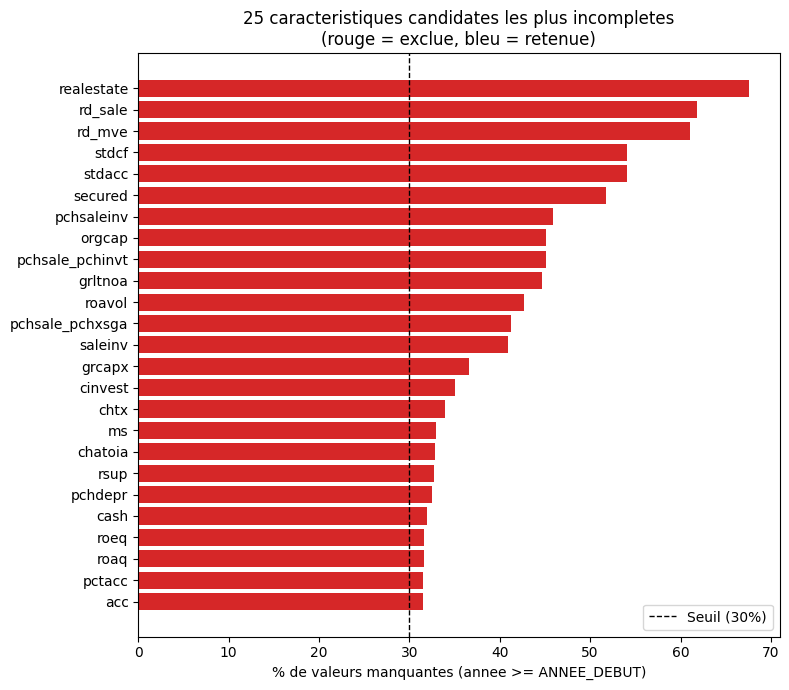

Manifeste sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\data\interim\caracteristiques_retenues.json


In [8]:
import matplotlib.pyplot as plt

# Visualisation : les candidates les plus incompletes, avec le seuil d'exclusion en repere
top_missing = taux_missing.head(25).sort_values()
couleurs = ['tab:red' if v > SEUIL_MISSING else 'tab:blue' for v in top_missing]

fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(top_missing))))
ax.barh(top_missing.index, top_missing.values * 100, color=couleurs)
ax.axvline(SEUIL_MISSING * 100, color='black', linewidth=1, linestyle='--',
           label=f"Seuil ({SEUIL_MISSING*100:.0f}%)")
ax.set_xlabel("% de valeurs manquantes (annee >= ANNEE_DEBUT)")
ax.set_title("25 caracteristiques candidates les plus incompletes\n(rouge = exclue, bleu = retenue)")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Sauvegarde du manifeste (liste retenue + taux de missing de TOUTES les candidates) --
# lu automatiquement par config.charger_caracteristiques_retenues() en aval (notebook 03
# partie B, et notebooks 04 a 06).
manifeste = {
    'seuil_max_pct_manquant': SEUIL_MISSING,
    'annee_debut': ANNEE_DEBUT,
    'caracteristiques_retenues': caracteristiques_gardees,
    'caracteristiques_exclues': caracteristiques_exclues,
    'taux_missing_pct': {c: round(float(taux_missing[c]) * 100, 3) for c in caracteristiques_candidates},
}
with open(config.FICHIER_CARACTERISTIQUES_RETENUES, 'w') as f:
    json.dump(manifeste, f, indent=2, ensure_ascii=False)
print("Manifeste sauvegarde :", config.FICHIER_CARACTERISTIQUES_RETENUES)

In [9]:
# On reduit le dataframe aux colonnes utiles : identifiants + secteur + caracteristiques
# RETENUES (apres le filtre de valeurs manquantes de A.3bis, pas les 94 candidates)
chars = chars[['permno', 'DATE', 'annee', 'sic2'] + caracteristiques_gardees].copy()
print("Dimensions apres reduction des colonnes :", chars.shape)
chars.head()

Dimensions apres reduction des colonnes : (3344804, 64)


,permno,DATE,annee,sic2,mvel1,beta,betasq,chmom,dolvol,idiovol,...,sp,tang,tb,baspread,ill,maxret,retvol,std_dolvol,std_turn,zerotrade
772496,10006,19800131,1980,37.0,303420.750,1.060420,1.124491,-1.846415e-01,11.152920,0.025576,...,3.063197,0.545459,0.173391,0.014234,2.565667e-08,0.025180,0.011128,0.881844,0.635898,1.115306e-07
772497,10057,19800131,1980,36.0,111423.125,1.526013,2.328716,1.502377e-01,9.541692,0.037473,...,2.973226,0.606464,0.439687,0.022470,2.719812e-07,0.063158,0.026207,1.368363,2.546787,6.199128e-08
772498,10058,19800131,1980,36.0,3127.500,0.417727,0.174496,5.535714e-01,NaN,0.095086,...,NaN,NaN,NaN,0.431111,NaN,0.111111,0.024845,NaN,NaN,NaN
772499,10065,19800131,1980,NaN,199206.000,0.549004,0.301405,4.574012e-02,9.393193,0.018695,...,NaN,NaN,NaN,0.018959,2.382967e-07,0.070000,0.022639,0.600856,0.201235,3.090190e-07
772500,10103,19800131,1980,33.0,2043.000,1.759493,3.095816,-1.686023e-08,NaN,0.087020,...,6.311635,0.576991,-0.753760,0.511667,NaN,0.250000,0.081946,NaN,NaN,NaN


### A.4 Valeurs manquantes des caractéristiques retenues

In [10]:
colonnes_manq = [c for c in caracteristiques_gardees]

print(f"Valeurs manquantes restantes parmi les {len(caracteristiques_gardees)} caracteristiques retenues "
      "(seront imputees au notebook 03, partie B, en % des lignes) :")
manquants = chars[colonnes_manq].isna().sum()
manquants = manquants[manquants > 0].sort_values(ascending=False)
if len(manquants) > 0:
    print((manquants / len(chars) * 100).round(2))
else:
    print("Aucune valeur manquante restante.")

Valeurs manquantes restantes parmi les 60 caracteristiques retenues (seront imputees au notebook 03, partie B, en % des lignes) :
tb               29.89
operprof         29.85
chinv            28.62
chpmia           28.28
pchgm_pchsale    28.11
sgr              28.09
chempia          28.00
hire             28.00
lgr              27.04
gma              26.94
chcsho           26.90
egr              26.86
agr              26.79
divo             26.79
ps               26.79
rd               26.79
divi             26.79
depr             26.53
cfp              26.40
cfp_ia           26.40
tang             25.58
cashdebt         24.65
quick            24.40
salerec          24.12
currat           23.95
roic             23.51
mom36m           22.88
cashpr           21.67
salecash         21.43
bm_ia            21.39
bm               21.39
dy               21.17
lev              21.04
sp               21.03
ep               20.84
mve_ia           20.84
herf             20.75
convind          20

### A.5 Nettoyage de la variable secteur (`sic2`)

`sic2` est un code numérique de secteur avec parfois des valeurs manquantes. On le
transforme en catégorie texte, avec une catégorie explicite `"Inconnu"` pour les
entreprises sans secteur renseigné (plutôt que de les exclure).

In [11]:
def nettoyer_secteur(valeur):
    if pd.isna(valeur):
        return "Inconnu"
    return str(int(valeur))

chars['secteur'] = chars['sic2'].apply(nettoyer_secteur)
chars = chars.drop(columns=['sic2'])

print("Repartition des secteurs (top 10) :")
chars['secteur'].value_counts().head(10)


Repartition des secteurs (top 10) :


secteur
67         393396
60         291885
73         268500
28         227216
36         190468
38         152757
35         148856
Inconnu    123948
13         116220
49         104153
Name: count, dtype: int64

### A.6 Vérification finale et sauvegarde

In [12]:
print("Dimensions finales :", chars.shape)
print("Colonnes finales   :", list(chars.columns))
print()
print("Valeurs manquantes restantes par colonne :")
print(chars.isna().sum())
print()
print("Rappel : mvel1 peut encore contenir des NaN a ce stade -- ces lignes ne sont PAS")
print("retirees ici mais au notebook 03, partie B (section B.3.1), juste avant le filtre de taille.")
print(f"Les {len(caracteristiques_gardees) - 1} autres caracteristiques retenues (apres le filtre de")
print("valeurs manquantes de A.3bis) peuvent egalement contenir des NaN residuels : elles seront")
print("imputees au notebook 03, partie B, apres les filtres de taille et de liquidite (section B.5")
print("ci-dessus).")

assert chars['permno'].isna().sum() == 0
assert chars['DATE'].isna().sum() == 0

Dimensions finales : (3344804, 64)
Colonnes finales   : ['permno', 'DATE', 'annee', 'mvel1', 'beta', 'betasq', 'chmom', 'dolvol', 'idiovol', 'indmom', 'mom1m', 'mom6m', 'mom12m', 'mom36m', 'pricedelay', 'turn', 'age', 'agr', 'bm', 'bm_ia', 'cashdebt', 'cashpr', 'cfp', 'cfp_ia', 'chcsho', 'chempia', 'chinv', 'chpmia', 'convind', 'currat', 'depr', 'divi', 'divo', 'dy', 'egr', 'ep', 'gma', 'herf', 'hire', 'lev', 'lgr', 'mve_ia', 'operprof', 'pchgm_pchsale', 'ps', 'quick', 'rd', 'roic', 'salecash', 'salerec', 'securedind', 'sgr', 'sin', 'sp', 'tang', 'tb', 'baspread', 'ill', 'maxret', 'retvol', 'std_dolvol', 'std_turn', 'zerotrade', 'secteur']

Valeurs manquantes restantes par colonne :
permno             0
DATE               0
annee              0
mvel1           1165
beta          315205
               ...  
retvol          2728
std_dolvol    110975
std_turn      101345
zerotrade     104935
secteur            0
Length: 64, dtype: int64

Rappel : mvel1 peut encore contenir des NaN a ce st

In [13]:
chars.describe().T


,count,mean,std,min,25%,50%,75%,max
permno,3344804.0,6.018914e+04,2.822724e+04,1.000000e+04,3.351600e+04,7.527200e+04,8.363100e+04,9.343600e+04
DATE,3344804.0,2.000220e+07,1.148780e+05,1.980013e+07,1.991043e+07,1.999123e+07,2.009123e+07,2.021123e+07
annee,3344804.0,2.000152e+03,1.148784e+01,1.980000e+03,1.991000e+03,1.999000e+03,2.009000e+03,2.021000e+03
mvel1,3343639.0,2.159091e+06,1.578347e+07,0.000000e+00,3.094775e+04,1.359149e+05,6.584343e+05,2.711977e+09
beta,3029599.0,1.021611e+00,6.720369e-01,-7.995801e-01,5.334524e-01,9.474190e-01,1.408684e+00,3.887420e+00
...,...,...,...,...,...,...,...,...
maxret,3344588.0,7.211179e-02,7.438007e-02,0.000000e+00,2.777778e-02,4.929578e-02,8.823530e-02,9.666665e-01
retvol,3342076.0,3.172540e-02,2.674325e-02,0.000000e+00,1.451218e-02,2.406174e-02,3.988190e-02,2.659367e-01
std_dolvol,3233829.0,8.573643e-01,4.322171e-01,0.000000e+00,5.061009e-01,7.766925e-01,1.138604e+00,3.362429e+00
std_turn,3243459.0,5.281880e+00,1.609422e+01,0.000000e+00,9.902795e-01,2.126279e+00,4.724407e+00,7.946859e+02


In [14]:
chars.to_parquet(config.FICHIER_CARACTERISTIQUES_CLEAN, index=False)
print("Fichier sauvegarde :", config.FICHIER_CARACTERISTIQUES_CLEAN)


Fichier sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\data\interim\characteristics_clean.parquet


**Résumé de la partie A :** base filtrée à partir de `ANNEE_DEBUT`, univers candidat des 94
caractéristiques de GKX (`config.CARACTERISTIQUES`) réduit automatiquement à celles dont le taux
de valeurs manquantes reste sous `config.SEUIL_MAX_PCT_MANQUANT_CARACTERISTIQUES` (section A.3bis) —
liste sauvegardée dans `data/interim/caracteristiques_retenues.json`, secteur nettoyé en catégorie
texte. `mvel1` et les autres caractéristiques retenues peuvent encore contenir des valeurs
manquantes résiduelles — c'est volontaire (voir l'encadré ℹ️ en tête de cette partie). Résultat
sauvegardé dans `data/interim/characteristics_clean.parquet`.

## Partie B — Nettoyage des rendements (`StockReturn.parquet`)

Cette partie lit `data/raw/StockReturn.parquet` et ne touche à aucun autre fichier. Elle sauvegarde
`data/interim/returns_clean.parquet`.

### B.1 Chargement des données brutes

In [15]:
returns = pd.read_parquet(config.FICHIER_RETURNS_BRUT)
print("Dimensions de depart :", returns.shape)
print("Type de la colonne RET :", returns['RET'].dtype)
returns.head(10)


Dimensions de depart : (4859751, 3)
Type de la colonne RET : str


,PERMNO,date,RET
0,10000,19851231,NaN
1,10000,19860131,C
2,10000,19860228,-0.257143
3,10000,19860331,0.365385
4,10000,19860430,-0.098592
5,10000,19860530,-0.222656
6,10000,19860630,-0.005025
7,10000,19860731,-0.080808
8,10000,19860829,-0.615385
9,10000,19860930,-0.057143


### B.2 Repérer les codes non numériques dans `RET`

La colonne `RET` de CRSP mélange des rendements numériques et des **codes texte spéciaux**
qui indiquent une raison précise pour laquelle le rendement est manquant (pas de cotation,
donnée insuffisante, société retirée de la cote, etc. — CRSP documente ces codes dans son
guide officiel, les significations exactes ne sont pas essentielles pour nous : dans tous
les cas, ces lignes n'ont **pas** de rendement utilisable).

In [16]:
# On essaie de convertir en nombre ; tout ce qui n'y arrive pas devient NaN
ret_numerique_test = pd.to_numeric(returns['RET'], errors='coerce')

# Valeurs presentes (non vides) mais qui ne sont PAS des nombres = codes speciaux CRSP
codes_speciaux = returns.loc[returns['RET'].notna() & ret_numerique_test.isna(), 'RET']

print("Codes non numeriques trouves dans RET :")
print(codes_speciaux.value_counts())
print()
print(f"Cela represente {len(codes_speciaux)} lignes sur {len(returns)} "
      f"({len(codes_speciaux) / len(returns) * 100:.2f} %)")


Codes non numeriques trouves dans RET :
RET
B    65232
C    39204
Name: count, dtype: int64

Cela represente 104436 lignes sur 4859751 (2.15 %)


### B.3 Conversion définitive de `RET` en numérique

On applique la conversion pour de bon. Les codes spéciaux et les cellules vides deviennent
tous des `NaN` (valeur manquante standard de pandas).

In [17]:
returns['RET'] = pd.to_numeric(returns['RET'], errors='coerce')

pct_manquant = returns['RET'].isna().mean() * 100
print(f"% de RET manquant apres conversion : {pct_manquant:.2f} %")


% de RET manquant apres conversion : 3.91 %


### B.4 Que faire des rendements manquants ?

**Règle importante, différente de la partie A :** on n'impute jamais la variable cible.
Remplacer un rendement manquant par une médiane reviendrait à *inventer* la donnée qu'on
cherche justement à prédire — ce serait une fuite de données (data leakage) qui fausserait
complètement l'évaluation du modèle.

La seule option raisonnable est de **retirer** les lignes où `RET` est manquant. On documente
combien de lignes ça représente avant de le faire.

In [18]:
avant = len(returns)
returns = returns.dropna(subset=['RET']).copy()
apres = len(returns)

print(f"Lignes avant suppression : {avant}")
print(f"Lignes apres suppression : {apres}")
print(f"Lignes supprimees : {avant - apres} ({(avant - apres) / avant * 100:.2f} %)")


Lignes avant suppression : 4859751
Lignes apres suppression : 4669780
Lignes supprimees : 189971 (3.91 %)


**Sur ton fichier complet**, si ce pourcentage dépasse largement 5-10 %, ça vaut le
coup d'investiguer pourquoi (une période particulière ? un sous-ensemble d'entreprises ?)
avant de continuer.

### B.5 Vérification des valeurs extrêmes (diagnostic)

Un rendement mensuel de +500 % ou -95 % est rare mais **pas forcément une erreur** — ça peut
arriver lors d'un delisting, d'une fusion, ou pour une action très volatile. On se contente
donc ici de les repérer, sans les supprimer automatiquement.

In [19]:
print("Statistiques descriptives de RET :")
print(returns['RET'].describe())
print()
print("Quantiles extremes :")
print(returns['RET'].quantile([0.001, 0.01, 0.5, 0.99, 0.999]))


Statistiques descriptives de RET :
count    4.669780e+06
mean     1.002258e-02
std      1.744961e-01
min     -9.958300e-01
25%     -5.816600e-02
50%      0.000000e+00
75%      6.185600e-02
max      3.900000e+01
Name: RET, dtype: float64

Quantiles extremes :
0.001   -0.636447
0.010   -0.380952
0.500    0.000000
0.990    0.541667
0.999    1.400000
Name: RET, dtype: float64


In [ ]:
seuil_extreme = 5.0  # +500%
nb_extremes_hauts = (returns['RET'] > seuil_extreme).sum()
nb_extremes_bas = (returns['RET'] < -0.95).sum()  # quasiment -100%

print(f"Rendements > +{seuil_extreme*100:.0f}% : {nb_extremes_hauts} lignes")
print(f"Rendements < -95% : {nb_extremes_bas} lignes")


Rendements > +500% : 155 lignes
Rendements < -95% : 30 lignes
(A garder en tete pour les modeles aux notebooks 04 a 06 : ces valeurs extremes
 peuvent influencer fortement une regression. On decidera a ce moment-la
 si on les traite specifiquement, selon leur frequence sur le fichier complet.)


### B.6 Harmonisation des identifiants et clé temporelle

Pour préparer la fusion du notebook 03 (partie A), on aligne les noms de colonnes avec ceux de
`characteristics_clean.parquet` (`permno` en minuscule) et on construit la même clé `annee_mois`
que dans les notebooks précédents.

In [21]:
returns = returns.rename(columns={'PERMNO': 'permno'})
returns['annee_mois'] = returns['date'].astype(str).str[:6]

returns[['permno', 'date', 'annee_mois', 'RET']].head()


,permno,date,annee_mois,RET
2,10000,19860228,198602,-0.257143
3,10000,19860331,198603,0.365385
4,10000,19860430,198604,-0.098592
5,10000,19860530,198605,-0.222656
6,10000,19860630,198606,-0.005025


In [22]:
# Verification : une seule ligne par (entreprise, mois) ? Sinon la fusion posera probleme.
doublons = returns.duplicated(subset=['permno', 'annee_mois']).sum()
print(f"Nombre de doublons (permno, annee_mois) : {doublons}")
if doublons > 0:
    print("ATTENTION : il faudra investiguer ces doublons avant la fusion (notebook 03, partie A).")


Nombre de doublons (permno, annee_mois) : 0


### B.7 Vérification finale et sauvegarde

In [23]:
print("Dimensions finales :", returns.shape)
print("Colonnes finales   :", list(returns.columns))
print("Periode couverte   : de", returns['annee_mois'].min(), "a", returns['annee_mois'].max())
print("Valeurs manquantes restantes :")
print(returns.isna().sum())


Dimensions finales : (4669780, 4)
Colonnes finales   : ['permno', 'date', 'RET', 'annee_mois']
Periode couverte   : de 195601 a 202412
Valeurs manquantes restantes :
permno        0
date          0
RET           0
annee_mois    0
dtype: int64


In [24]:
returns_finales = returns[['permno', 'annee_mois', 'RET']]
returns_finales.to_parquet(config.FICHIER_RETURNS_CLEAN, index=False)
print("Fichier sauvegarde :", config.FICHIER_RETURNS_CLEAN)


Fichier sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\data\interim\returns_clean.parquet


**Résumé de la partie B :** codes CRSP non numériques (ex: `"C"`) convertis en valeurs
manquantes, lignes avec `RET` manquant supprimées (jamais imputées, car c'est la variable
cible), valeurs extrêmes repérées mais non modifiées (décision reportée aux notebooks de
modélisation). Colonnes harmonisées (`permno`, `annee_mois`). Résultat sauvegardé dans
`data/interim/returns_clean.parquet`.

## Partie C — Nettoyage des variables macro (`MacroData.parquet`)

Cette partie lit `data/raw/MacroData.parquet` et ne touche à aucun autre fichier. Elle sauvegarde
`data/interim/macro_clean.parquet`.

### C.1 Chargement des données brutes

In [25]:
macro = pd.read_parquet(config.FICHIER_MACRO_BRUT)
print("Dimensions de depart :", macro.shape)
print("Colonnes :", list(macro.columns))
print("Periode couverte (yyyymm) : de", macro['yyyymm'].min(), "a", macro['yyyymm'].max())
macro.head()


Dimensions de depart : (1860, 18)
Colonnes : ['yyyymm', 'Index', 'D12', 'E12', 'b/m', 'tbl', 'AAA', 'BAA', 'lty', 'ntis', 'Rfree', 'infl', 'ltr', 'corpr', 'svar', 'csp', 'CRSP_SPvw', 'CRSP_SPvwx']
Periode couverte (yyyymm) : de 187101 a 202512


,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx
0,187101,4.44,0.26,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,187102,4.50,0.26,0.4,NaN,NaN,NaN,NaN,NaN,NaN,0.004967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,187103,4.61,0.26,0.4,NaN,NaN,NaN,NaN,NaN,NaN,0.004525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,187104,4.74,0.26,0.4,NaN,NaN,NaN,NaN,NaN,NaN,0.004252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,187105,4.86,0.26,0.4,NaN,NaN,NaN,NaN,NaN,NaN,0.004643,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### C.1bis Forcer la conversion numérique de toutes les colonnes

Les fichiers Welch & Goyal contiennent souvent de grands nombres formatés avec une virgule
comme séparateur de milliers (ex: `"4,796.56"` pour `Index`). Pandas ne sait pas convertir
ça automatiquement en nombre, et la colonne entière reste alors en texte — ce qui casse
n'importe quel calcul ou comparaison dessus (`<=`, `log`, etc.), souvent avec une erreur peu
claire. On force donc explicitement la conversion, en retirant d'abord les virgules.

In [26]:
colonnes_a_convertir = [c for c in macro.columns if c != 'yyyymm']

for col in colonnes_a_convertir:
    macro[col] = pd.to_numeric(
        macro[col].astype(str).str.replace(',', '', regex=False),
        errors='coerce'
    )

print("Types de donnees apres conversion :")
print(macro.dtypes)


Types de donnees apres conversion :
yyyymm          int64
Index         float64
D12           float64
E12           float64
b/m           float64
tbl           float64
AAA           float64
BAA           float64
lty           float64
ntis          float64
Rfree         float64
infl          float64
ltr           float64
corpr         float64
svar          float64
csp           float64
CRSP_SPvw     float64
CRSP_SPvwx    float64
dtype: object


### C.2 Restreindre à la période utile

`ANNEE_DEBUT` vient de `config.py` — **la même valeur que celle utilisée à la partie A**,
automatiquement (plus besoin de vérifier toi-même que les deux correspondent).

In [27]:
ANNEE_DEBUT = config.ANNEE_DEBUT
print(f"ANNEE_DEBUT (depuis config.py) : {ANNEE_DEBUT}")

macro['annee'] = macro['yyyymm'] // 100
macro = macro[macro['annee'] >= ANNEE_DEBUT].copy()
print(f"Dimensions apres filtre sur annee >= {ANNEE_DEBUT} :", macro.shape)


ANNEE_DEBUT (depuis config.py) : 1980
Dimensions apres filtre sur annee >= 1980 : (552, 19)


### C.3 Vérifier les valeurs manquantes sur cette période

Contrairement aux caractéristiques d'entreprises (partie A), il n'y a **qu'une seule
ligne par mois** ici — pas de dimension "entreprise" pour calculer une médiane croisée.
On utilise donc une logique différente : si une valeur manque un mois donné, on la
remplace par la **dernière valeur connue** (`ffill`, standard pour les séries temporelles
macro qui évoluent lentement), avec un `bfill` en secours pour un éventuel trou en tout
début de période.

In [28]:
colonnes_macro = [c for c in macro.columns if c not in ['yyyymm', 'annee']]

print("Pourcentage de valeurs manquantes par colonne, sur la periode choisie :")
(macro[colonnes_macro].isna().mean() * 100).round(1).sort_values(ascending=False)


Pourcentage de valeurs manquantes par colonne, sur la periode choisie :


csp           50.0
Index          0.0
D12            0.0
b/m            0.0
E12            0.0
AAA            0.0
BAA            0.0
lty            0.0
tbl            0.0
ntis           0.0
Rfree          0.0
ltr            0.0
infl           0.0
corpr          0.0
svar           0.0
CRSP_SPvw      0.0
CRSP_SPvwx     0.0
dtype: float64

In [29]:
colonnes_entierement_vides = []

for col in colonnes_macro:
    macro[col] = macro[col].ffill().bfill()
    # si une colonne n'a AUCUNE valeur sur toute la periode, ffill/bfill ne peuvent rien faire
    if macro[col].isna().any():
        colonnes_entierement_vides.append(col)

print("Comblement des trous termine (ffill puis bfill).")
if colonnes_entierement_vides:
    print()
    print("ATTENTION - ces colonnes sont ENTIEREMENT vides sur la periode choisie :")
    print(colonnes_entierement_vides)
    print("-> soit tu avances ANNEE_DEBUT, soit tu ne pourras pas utiliser ces colonnes.")


Comblement des trous termine (ffill puis bfill).


### C.4 Construire les 8 prédicteurs macro de Gu, Kelly & Xiu (2020)

GKX n'utilisent pas toutes les colonnes de Welch & Goyal telles quelles : ils en retiennent
**8**, dont certaines sont calculées à partir des colonnes brutes :

| Prédicteur GKX | Nom de colonne final | Signification | Calcul |
|---|---|---|---|
| `dp` | `macro_dp` | dividend-price ratio | `log(D12) - log(Index)` |
| `ep` | `macro_ep` | earnings-price ratio | `log(E12) - log(Index)` |
| `bm` | `macro_bm` | book-to-market du marché | colonne `b/m` directement |
| `ntis` | `macro_ntis` | net equity expansion | colonne `ntis` directement |
| `tbl` | `macro_tbl` | taux des bons du Tresor | colonne `tbl` directement |
| `tms` | `macro_tms` | term spread | `lty - tbl` |
| `dfy` | `macro_dfy` | default spread | `BAA - AAA` |
| `svar` | `macro_svar` | variance du marche actions | colonne `svar` directement |

⚠️ **Pourquoi le préfixe `macro_` ?** Les caractéristiques d'entreprise de la partie A
contiennent déjà des colonnes nommées `bm` et `ep` (book-to-market / earnings-price **de
l'entreprise**). Sans préfixe, la fusion du notebook 03 (partie A) renommerait silencieusement les deux
versions en `bm_x` / `bm_y` sans erreur explicite — un piège classique. Préfixer clarifie
aussi qu'il s'agit d'une variable de marché global, pas d'une caractéristique par entreprise.

Note additionnelle : `dp` et `ep` sont calculés ici de façon simplifiée (log du ratio du même
mois). Le papier original de Welch & Goyal utilise une définition légèrement plus précise
(somme glissante sur 12 mois, décalage temporel). 

In [30]:
# Securite : le log n'est defini que pour des valeurs strictement positives
for col in ['Index', 'D12', 'E12']:
    nb_non_positif = (macro[col] <= 0).sum()
    if nb_non_positif > 0:
        print(f"ATTENTION : {nb_non_positif} valeurs <= 0 dans '{col}', le log sera NaN pour ces lignes.")

# On prefixe volontairement toutes ces colonnes par "macro_" : la base des
# caracteristiques d'entreprise (partie A) contient DEJA des colonnes nommees
# 'bm' et 'ep' (book-to-market / earnings-price de l'ENTREPRISE). Sans prefixe,
# la fusion du notebook 03 (partie A) renommerait silencieusement les deux versions en
# 'bm_x'/'bm_y', ce qui casserait tout sans erreur visible immediatement.
macro['macro_dp'] = np.log(macro['D12']) - np.log(macro['Index'])
macro['macro_ep'] = np.log(macro['E12']) - np.log(macro['Index'])
macro['macro_bm'] = macro['b/m']
macro['macro_ntis'] = macro['ntis']
macro['macro_tbl'] = macro['tbl']
macro['macro_tms'] = macro['lty'] - macro['tbl']
macro['macro_dfy'] = macro['BAA'] - macro['AAA']
macro['macro_svar'] = macro['svar']

predicteurs_gkx = config.MACRO_PREDICTEURS

macro[predicteurs_gkx].head()


,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,macro_dfy,macro_svar
1308,-2.997135,-2.029331,1.016955,0.011297,0.1200,-0.0086,0.0133,0.001906
1309,-2.984012,-2.015429,1.031930,0.010827,0.1286,-0.0100,0.0119,0.001898
1310,-2.867997,-1.898656,1.093732,0.011877,0.1520,-0.0281,0.0149,0.004622
1311,-2.900294,-1.946634,1.051820,0.015348,0.1320,-0.0244,0.0215,0.002746
1312,-2.937874,-1.999867,1.010049,0.015052,0.0858,0.0179,0.0218,0.001510


In [31]:
print("Valeurs manquantes dans les 8 predicteurs GKX, sur la periode choisie :")
macro[predicteurs_gkx].isna().sum()


Valeurs manquantes dans les 8 predicteurs GKX, sur la periode choisie :


macro_dp      0
macro_ep      0
macro_bm      0
macro_ntis    0
macro_tbl     0
macro_tms     0
macro_dfy     0
macro_svar    0
dtype: int64

### C.5 Clé temporelle et sélection finale des colonnes

On garde `Rfree` séparément (pas un prédicteur, mais nécessaire au notebook 03 (partie A) pour calculer
le rendement excédentaire), et on construit `annee_mois` comme dans les notebooks précédents.

In [32]:
macro['annee_mois'] = macro['yyyymm'].astype(str)

macro_final = macro[['annee_mois'] + predicteurs_gkx + ['Rfree']].copy()
macro_final.head()


,annee_mois,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,macro_dfy,macro_svar,Rfree
1308,198001,-2.997135,-2.029331,1.016955,0.011297,0.1200,-0.0086,0.0133,0.001906,0.0080
1309,198002,-2.984012,-2.015429,1.031930,0.010827,0.1286,-0.0100,0.0119,0.001898,0.0089
1310,198003,-2.867997,-1.898656,1.093732,0.011877,0.1520,-0.0281,0.0149,0.004622,0.0121
1311,198004,-2.900294,-1.946634,1.051820,0.015348,0.1320,-0.0244,0.0215,0.002746,0.0126
1312,198005,-2.937874,-1.999867,1.010049,0.015052,0.0858,0.0179,0.0218,0.001510,0.0081


### C.6 Vérification finale et sauvegarde

In [33]:
print("Dimensions finales :", macro_final.shape)
print("Colonnes finales   :", list(macro_final.columns))
print()
print("Valeurs manquantes restantes :")
print(macro_final.isna().sum())


Dimensions finales : (552, 10)
Colonnes finales   : ['annee_mois', 'macro_dp', 'macro_ep', 'macro_bm', 'macro_ntis', 'macro_tbl', 'macro_tms', 'macro_dfy', 'macro_svar', 'Rfree']

Valeurs manquantes restantes :
annee_mois    0
macro_dp      0
macro_ep      0
macro_bm      0
macro_ntis    0
macro_tbl     0
macro_tms     0
macro_dfy     0
macro_svar    0
Rfree         0
dtype: int64


In [34]:
macro_final.to_parquet(config.FICHIER_MACRO_CLEAN, index=False)
print("Fichier sauvegarde :", config.FICHIER_MACRO_CLEAN)


Fichier sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\data\interim\macro_clean.parquet


**Résumé de la partie C :** base restreinte à `annee >= ANNEE_DEBUT` (identique à la
partie A), valeurs manquantes comblées par `ffill`/`bfill` (adapté aux séries temporelles),
construction des 8 prédicteurs macro de GKX (`config.MACRO_PREDICTEURS`), `Rfree` conservé
séparément. Résultat sauvegardé dans `data/interim/macro_clean.parquet`.

## Résumé global

Les 3 fichiers nettoyés sont maintenant disponibles dans `data/interim/` :
- `characteristics_clean.parquet` (Partie A) — peut encore contenir des valeurs manquantes
  (volontaire, voir Partie A)
- `returns_clean.parquet` (Partie B) — plus aucune valeur manquante dans `RET` (lignes supprimées,
  jamais imputées)
- `macro_clean.parquet` (Partie C) — plus aucune valeur manquante (comblées par `ffill`/`bfill`)